# Analyse Exploratoire des Données (EDA)
## Dataset : PIMA Indians Diabetes
**Projet PFA — Prédiction du Diabète par IA**

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

os.makedirs('../../../data/processed', exist_ok=True)

print('Librairies chargées.')

Librairies chargées.


---
## Section 1 — Chargement des données

In [2]:
df = pd.read_csv('../../../data/raw/pima_diabetes.csv')

print('=== SHAPE ===')
print(f'{df.shape[0]} lignes, {df.shape[1]} colonnes\n')

print('=== TYPES ===')
print(df.dtypes)
print()

=== SHAPE ===
768 lignes, 9 colonnes

=== TYPES ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object



In [3]:
print('=== STATISTIQUES DESCRIPTIVES ===')
df.describe().round(2)

=== STATISTIQUES DESCRIPTIVES ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [4]:
print('=== 5 PREMIÈRES LIGNES ===')
df.head()

=== 5 PREMIÈRES LIGNES ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Section 2 — Valeurs manquantes (zéros invalides)

=== ZÉROS INVALIDES PAR COLONNE ===
               Zéros  Pourcentage (%)
Glucose            5              0.7
BloodPressure     35              4.6
SkinThickness    227             29.6
Insulin          374             48.7
BMI               11              1.4


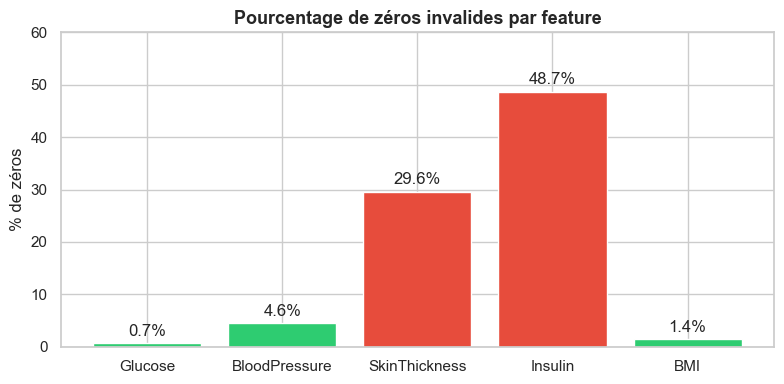

In [5]:
# Ces colonnes ne peuvent pas biologiquement valoir 0 — les zéros sont des données manquantes masquées
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_report = pd.DataFrame({
    'Zéros': [(df[col] == 0).sum() for col in zero_cols],
    'Pourcentage (%)': [(df[col] == 0).sum() / len(df) * 100 for col in zero_cols]
}, index=zero_cols).round(1)

print('=== ZÉROS INVALIDES PAR COLONNE ===')
print(zero_report)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(zero_report.index, zero_report['Pourcentage (%)'],
              color=['#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#2ecc71'
                     for v in zero_report['Pourcentage (%)']])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title('Pourcentage de zéros invalides par feature', fontsize=13, fontweight='bold')
ax.set_ylabel('% de zéros')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

---
## Section 3 — Distributions par feature

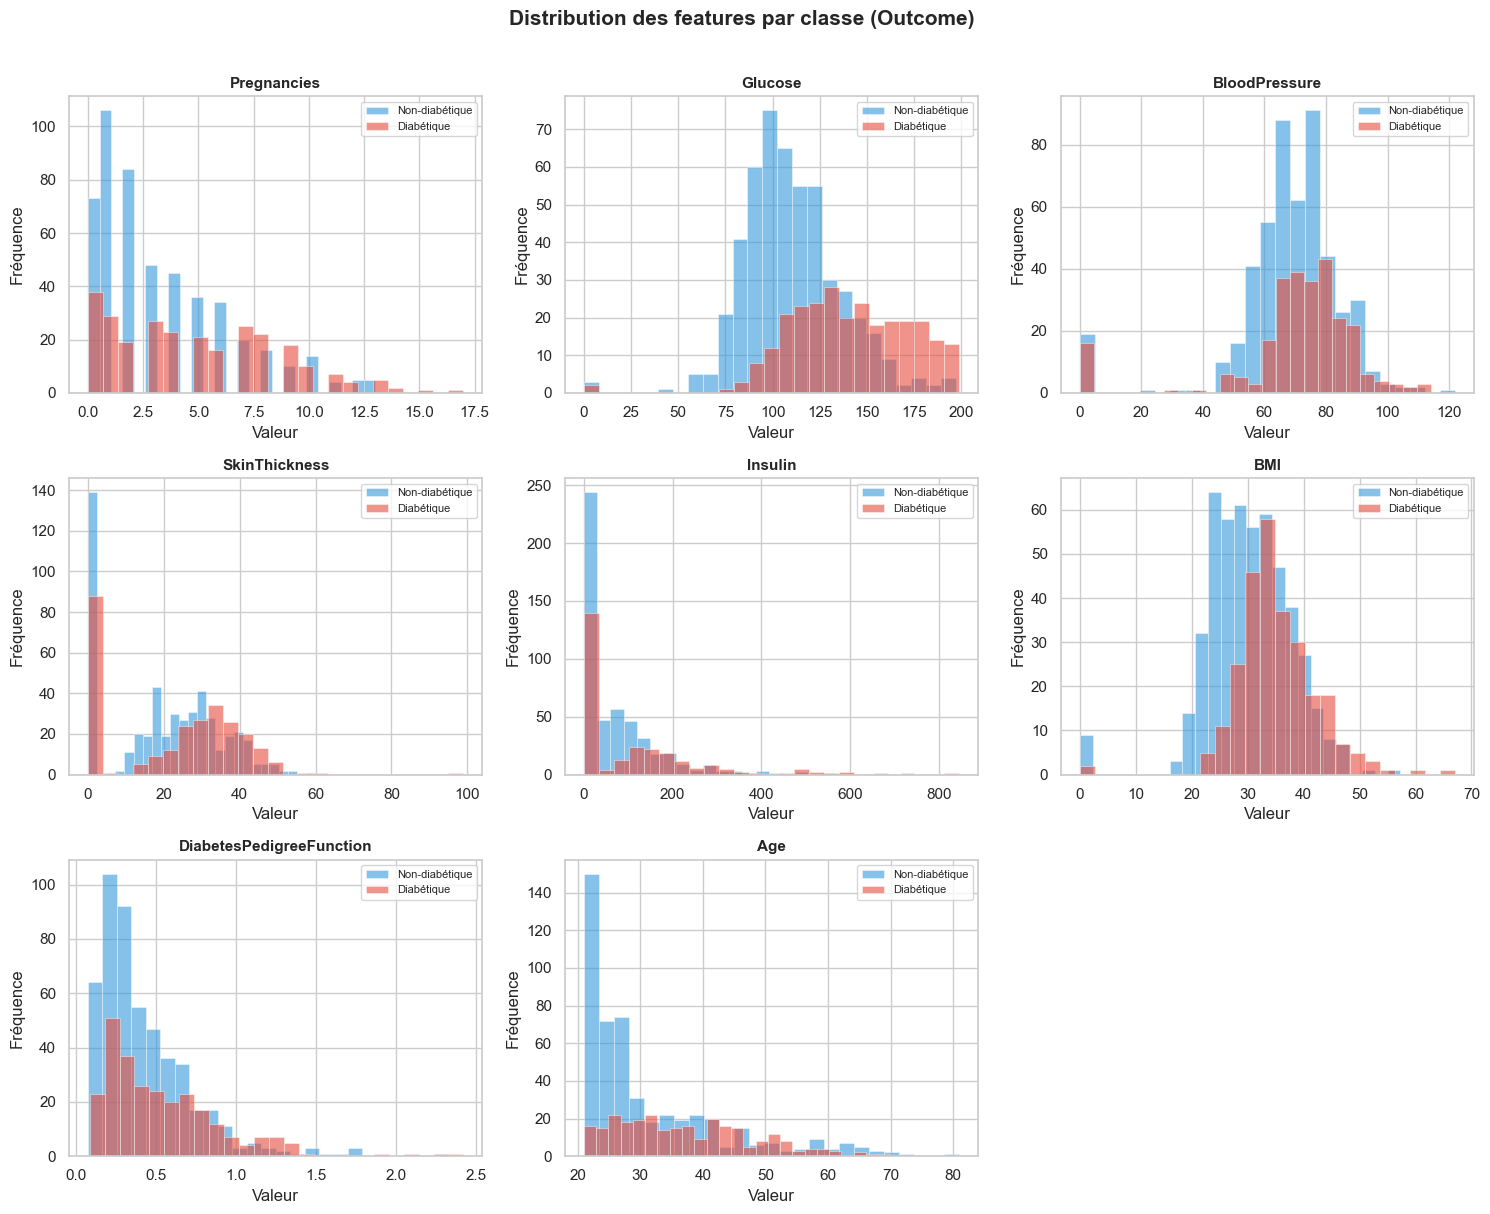

In [6]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

palette = {0: '#3498db', 1: '#e74c3c'}
labels = {0: 'Non-diabétique', 1: 'Diabétique'}

for i, feature in enumerate(features):
    ax = axes[i]
    for outcome in [0, 1]:
        subset = df[df['Outcome'] == outcome][feature]
        ax.hist(subset, bins=25, alpha=0.6, color=palette[outcome],
                label=labels[outcome], edgecolor='white', linewidth=0.5)
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)

# Masquer le 9e subplot vide
axes[-1].set_visible(False)

fig.suptitle('Distribution des features par classe (Outcome)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 4 — Corrélations

Heatmap sauvegardée → ../../../data/processed/correlation_heatmap.png


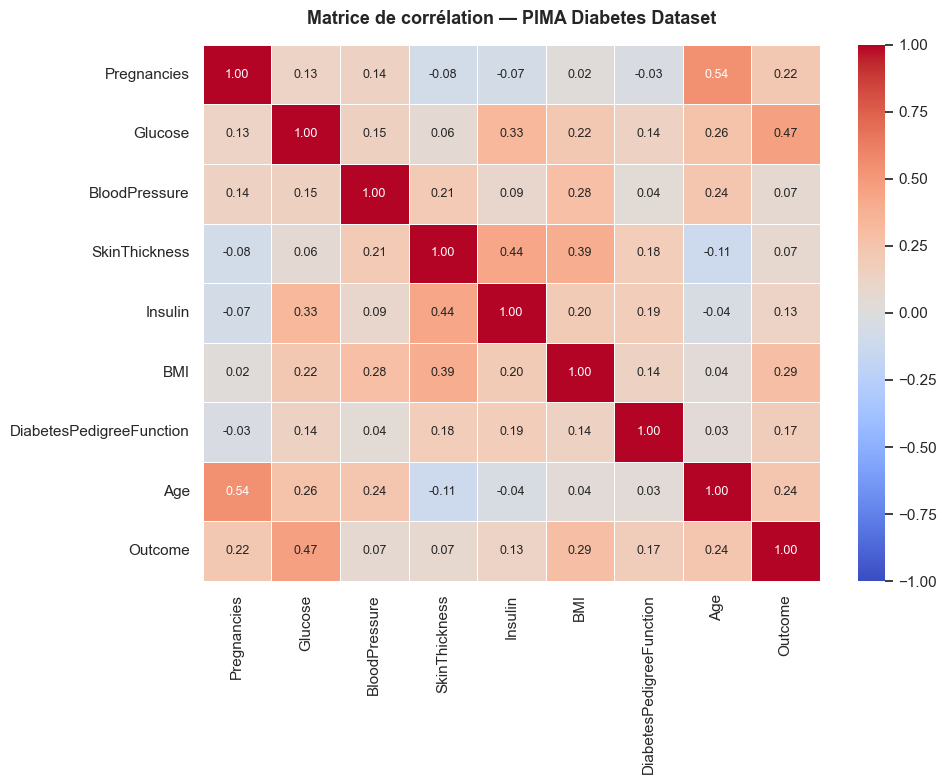


=== CORRÉLATIONS AVEC OUTCOME (triées) ===
Glucose                     0.467
BMI                         0.293
Age                         0.238
Pregnancies                 0.222
DiabetesPedigreeFunction    0.174
Insulin                     0.131
SkinThickness               0.075
BloodPressure               0.065
Name: Outcome, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)

ax.set_title('Matrice de corrélation — PIMA Diabetes Dataset',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()

save_path = '../../../data/processed/correlation_heatmap.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Heatmap sauvegardée → {save_path}')
plt.show()

# Top corrélations avec Outcome
print('\n=== CORRÉLATIONS AVEC OUTCOME (triées) ===')
print(corr_matrix['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

---
## Section 5 — Déséquilibre des classes

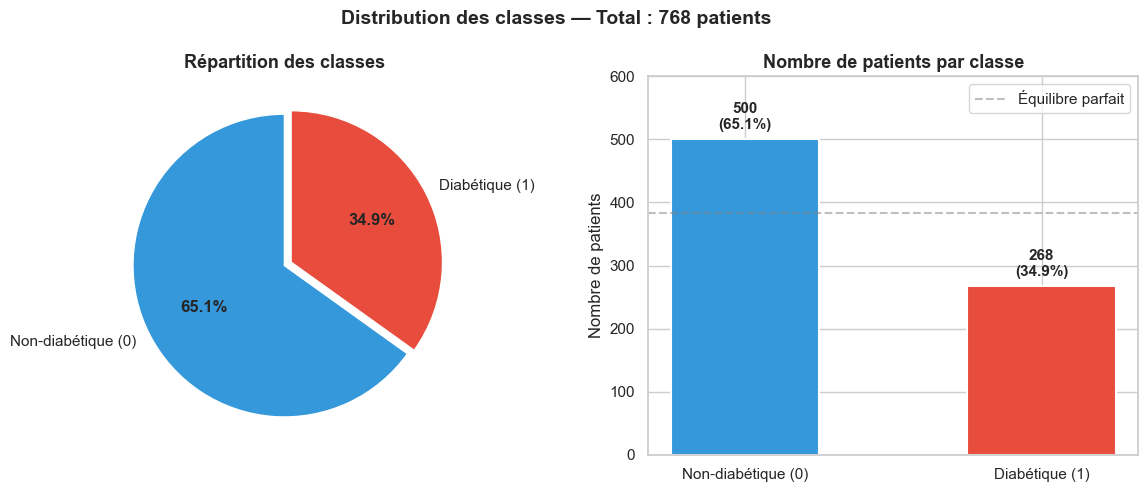

Ratio Non-diabétique/Diabétique : 1.87:1
→ Dataset modérément déséquilibré (ratio ~1.87:1)


In [8]:
counts = df['Outcome'].value_counts()
labels_pie = ['Non-diabétique (0)', 'Diabétique (1)']
colors = ['#3498db', '#e74c3c']
explode = (0, 0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
wedges, texts, autotexts = ax1.pie(
    counts,
    labels=labels_pie,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax1.set_title('Répartition des classes', fontsize=13, fontweight='bold')

# Bar chart
bars = ax2.bar(labels_pie, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
ax2.bar_label(bars, labels=[f'{v}\n({v/len(df)*100:.1f}%)' for v in counts.values],
              padding=5, fontsize=11, fontweight='bold')
ax2.set_title('Nombre de patients par classe', fontsize=13, fontweight='bold')
ax2.set_ylabel('Nombre de patients')
ax2.set_ylim(0, 600)
ax2.axhline(y=len(df)/2, color='gray', linestyle='--', alpha=0.5, label='Équilibre parfait')
ax2.legend()

fig.suptitle(f'Distribution des classes — Total : {len(df)} patients',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ratio = counts[0] / counts[1]
print(f'Ratio Non-diabétique/Diabétique : {ratio:.2f}:1')
print(f'→ Dataset modérément déséquilibré (ratio ~1.87:1)')

---
## Section 6 — Détection des outliers

C:\Users\salma\AppData\Local\Temp\ipykernel_17776\2703725164.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True,
C:\Users\salma\AppData\Local\Temp\ipykernel_17776\2703725164.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True,
C:\Users\salma\AppData\Local\Temp\ipykernel_17776\2703725164.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, patch_artist=True,
C:\Users\salma\AppData\Local\Temp\ipykernel_17776\2703725164.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been re

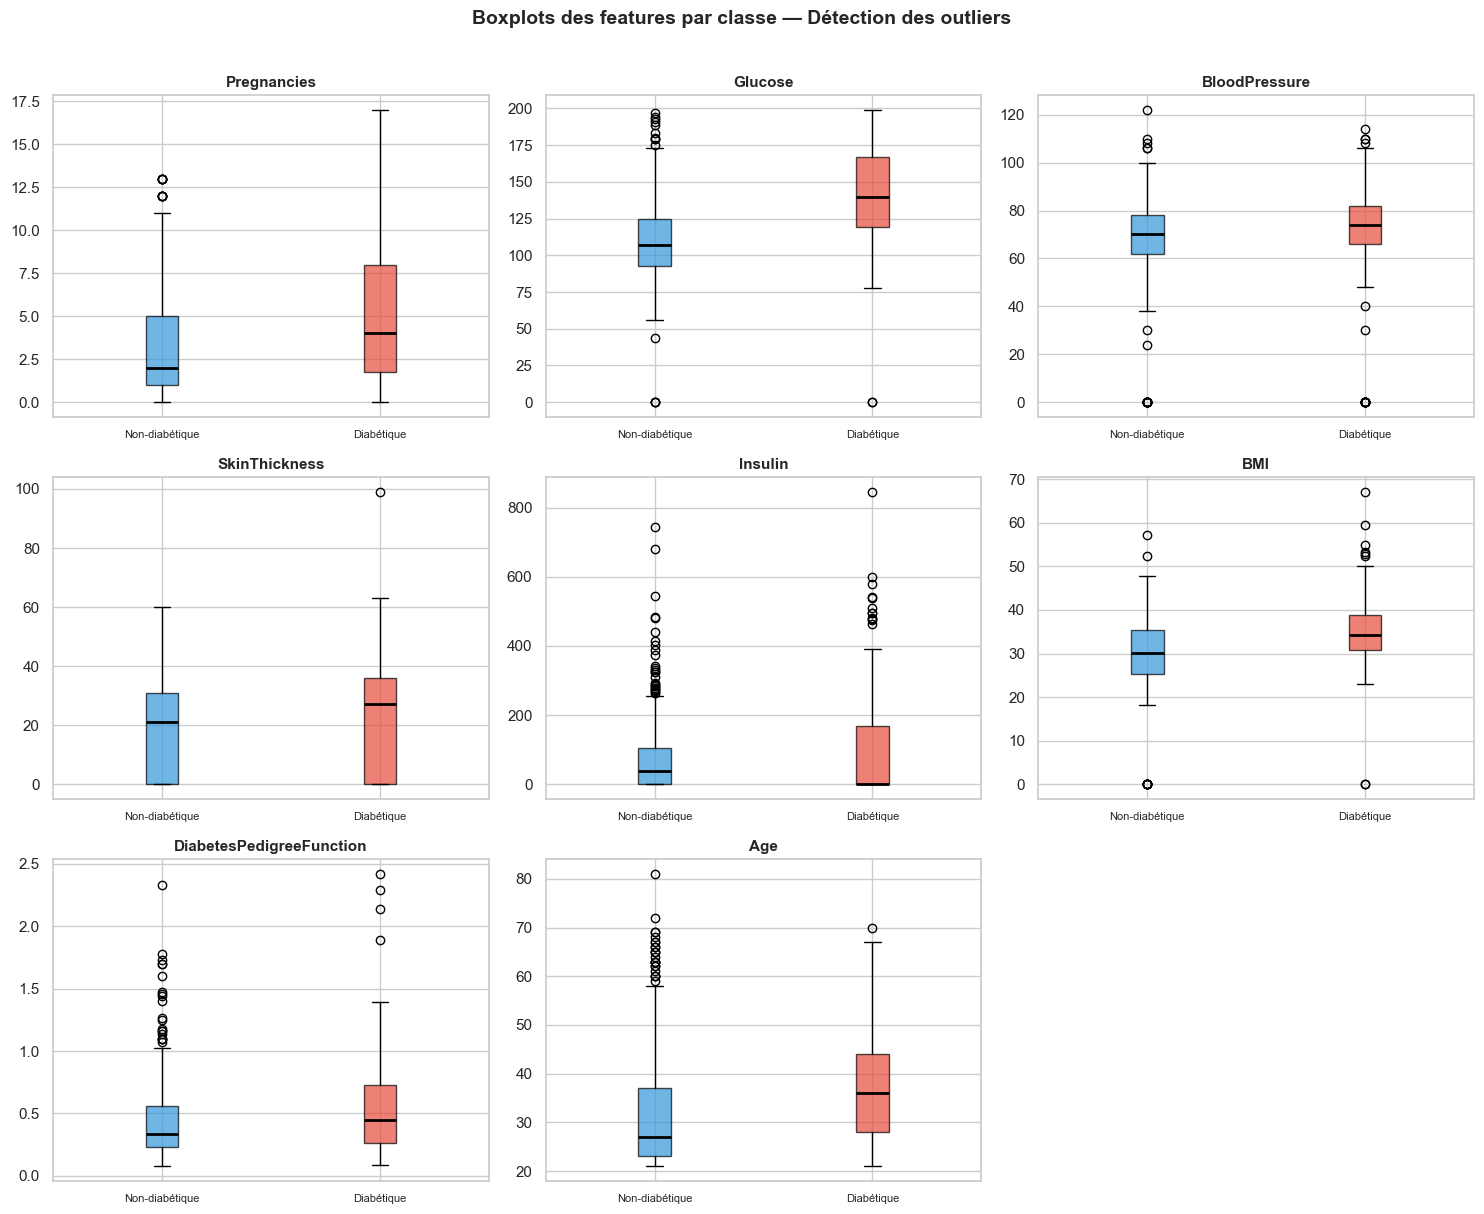

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    data_plot = [
        df[df['Outcome'] == 0][feature].values,
        df[df['Outcome'] == 1][feature].values
    ]
    bp = ax.boxplot(data_plot, patch_artist=True,
                    labels=['Non-diabétique', 'Diabétique'],
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Boxplots des features par classe — Détection des outliers',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Analyse détaillée des outliers dans Insulin (colonne la plus problématique)
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_insulin = df[(df['Insulin'] < lower) | (df['Insulin'] > upper)]

print('=== OUTLIERS INSULIN (méthode IQR) ===')
print(f'Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
print(f'Borne inférieure : {lower:.1f}')
print(f'Borne supérieure : {upper:.1f}')
print(f'Nombre d\'outliers : {len(outliers_insulin)} ({len(outliers_insulin)/len(df)*100:.1f}%)')
print(f'Valeur max observée : {df["Insulin"].max()}')
print(f'\nTop 10 valeurs extrêmes :')
print(df.nlargest(10, 'Insulin')[['Insulin', 'Glucose', 'BMI', 'Outcome']].to_string(index=False))

=== OUTLIERS INSULIN (méthode IQR) ===
Q1=0.0, Q3=127.2, IQR=127.2
Borne inférieure : -190.9
Borne supérieure : 318.1
Nombre d'outliers : 34 (4.4%)
Valeur max observée : 846

Top 10 valeurs extrêmes :
 Insulin  Glucose  BMI  Outcome
     846      189 30.1        1
     744      197 36.7        0
     680      165 52.3        0
     600      124 28.7        1
     579      172 42.4        1
     545      155 38.7        0
     543      197 30.5        1
     540      155 38.7        1
     510      181 43.3        1
     495      155 34.0        1


---
## Section 7 — Insights et observations clés

### Résumé de l'EDA pour le rapport de PFA

---

#### Observation 1 — Données manquantes masquées
Cinq variables présentent des **zéros biologiquement impossibles** qui représentent en réalité des données manquantes :
- **Insulin** : ~48.7% de zéros → variable la plus affectée, à imputer avec précaution
- **SkinThickness** : ~29.6% de zéros
- **BloodPressure**, **BMI**, **Glucose** : moins de 5% → impact plus limité

> **Impact sur la modélisation** : une imputation (médiane par groupe ou KNN) sera nécessaire avant l'entraînement.

---

#### Observation 2 — Features les plus discriminantes
D'après la matrice de corrélation et les distributions, les variables les plus corrélées avec le diagnostic (**Outcome**) sont :
1. **Glucose** (r ≈ 0.47) — prédicteur le plus fort
2. **BMI** (r ≈ 0.29)
3. **Age** (r ≈ 0.24)
4. **DiabetesPedigreeFunction** (r ≈ 0.17) — facteur héréditaire

> **Impact sur la modélisation** : Glucose devrait apparaître parmi les features les plus importantes dans tous les modèles (Random Forest, XGBoost).

---

#### Observation 3 — Déséquilibre des classes
Le dataset présente un **déséquilibre modéré** : 500 non-diabétiques (65.1%) vs 268 diabétiques (34.9%), soit un ratio de ~1.87:1.

> **Impact sur la modélisation** : utiliser `class_weight='balanced'` ou SMOTE pour éviter que le modèle ne favorise systématiquement la classe majoritaire. Privilégier **F1-score** et **AUC-ROC** comme métriques plutôt que l'accuracy simple.

---

#### Observation 4 — Outliers dans Insulin
La variable **Insulin** présente des valeurs extrêmes significatives (jusqu'à 846 µU/mL, soit ~8x la borne IQR supérieure). Ces valeurs concernent ~5% du dataset et peuvent dégrader les performances de modèles sensibles aux outliers (Régression Logistique, SVM).

> **Impact sur la modélisation** : appliquer une transformation logarithmique (`log1p`) ou un clipping sur Insulin avant la normalisation.

---

#### Observation 5 — Distributions et séparabilité
Les histogrammes montrent que les distributions des patients diabétiques vs non-diabétiques **se chevauchent significativement** pour la plupart des features. Il n'existe pas de seuil unique permettant une séparation parfaite, ce qui justifie l'utilisation de modèles ensemblistes (Random Forest, XGBoost) plutôt que des modèles linéaires simples.

> **Recommandation** : tester et comparer au minimum : Régression Logistique (baseline), Random Forest, XGBoost, et SVM avec kernel RBF.

---

### Pipeline de prétraitement recommandé
```
1. Remplacer les 0 invalides par NaN dans les 5 colonnes identifiées
2. Imputer les NaN (médiane par groupe Outcome ou KNNImputer)
3. Transformation log1p sur Insulin
4. StandardScaler sur toutes les features numériques
5. Stratified train/test split (80/20) pour respecter le ratio de classes
```